# PhyloCartoPlot Raster Visualization - Complete Walkthrough

This notebook demonstrates how to use the refactored `PhyloCartoPlotter` class to create phylogeographic visualizations with both **raster layers** and **geographic maps**.

## What You'll Learn:
- Import and initialize `PhyloCartoPlotter`
- Create visualizations with raster data
- Create visualizations with geographic maps
- Customize colors, contrast, and parameters
- Save outputs as SVG and PNG

## Setup

Configure paths to find your data and scripts.

In [1]:
import sys
from pathlib import Path

# Find workflow directory and add scripts to path
def find_workflow_dir():
    """Find workflow_dir by looking for the input and scripts folders"""
    current = Path.cwd()
    
    # Check current directory
    if (current / 'input').exists() and (current / 'scripts').exists():
        return current
    
    # Check parent
    if (current.parent / 'input').exists() and (current.parent / 'scripts').exists():
        return current.parent
    
    # Check grandparent
    if (current.parent.parent / 'input').exists() and (current.parent.parent / 'scripts').exists():
        return current.parent.parent
    
    raise FileNotFoundError("Could not find workflow directory with 'input' and 'scripts' folders")

workflow_dir = find_workflow_dir()
scripts_dir = workflow_dir / 'scripts'
visualization_dir = scripts_dir / 'visualisation'
input_dir = workflow_dir / 'input/use_case_2'
output_dir = workflow_dir / 'output/use_case_2'

# Add visualization scripts to path
sys.path.insert(0, str(visualization_dir))

print("Workflow Configuration")
print("="*70)
print(f"Workflow:       {workflow_dir}")
print(f"Scripts:        {scripts_dir}")
print(f"Visualization:  {visualization_dir}")
print(f"Input:          {input_dir}")
print(f"Output:         {output_dir}")
print("="*70)
print("\n✓ Paths configured")

Workflow Configuration
Workflow:       c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot
Scripts:        c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\scripts
Visualization:  c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\scripts\visualisation
Input:          c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\input\use_case_2
Output:         c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\use_case_2

✓ Paths configured


## Import Classes

Import `PhyloCartoPlotter` from the visualization module.

In [2]:
from tree_to_map_raster import PhyloCartoPlotter

print("✓ PhyloCartoPlotter imported successfully")

✓ PhyloCartoPlotter imported successfully


## Example 2: Visualization with Geographic Map (No Raster)

Create a visualization with just the geographic map and coastlines.

In [19]:
# Initialize plotter WITHOUT raster data
plotter_map = PhyloCartoPlotter(
    nwk_file=str(input_dir / 'Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree.nwk'),
    gps_file=str(input_dir / 'Updated_Dataset_Tree_ID.csv'),
    offset_file=str(input_dir / 'offsets0.csv'),
    # Note: NO raster_file parameter
    extent = [-32, -10, 55, 69],
    vmin=0.01,
    vmax=0.06,
    trait_name='Oceanic sector',
    verbose=True
)

print("\n✓ Map plotter initialized")

PhyloCartoPlot: Loading Data

Loading data...
  Tree:    c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\input\use_case_2\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree.nwk
  GPS:     c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\input\use_case_2\Updated_Dataset_Tree_ID.csv
  Offsets: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\input\use_case_2\offsets0.csv
  ✓ Loaded tree with 62 species
  ✓ Loaded 62 GPS records
  ✓ Loaded 62 node offsets

Configuration:
  Display mode:       Geographic map
  Map extent:         [-32, -10, 55, 69]
  Trait name:         Oceanic sector
  Trait value range:  0.010000 - 0.060000

✓ Map plotter initialized


### Create and Display


Creating visualization...
  ✓ Tree plotted
  ✓ Map plotted
  ✓ Connection lines drawn


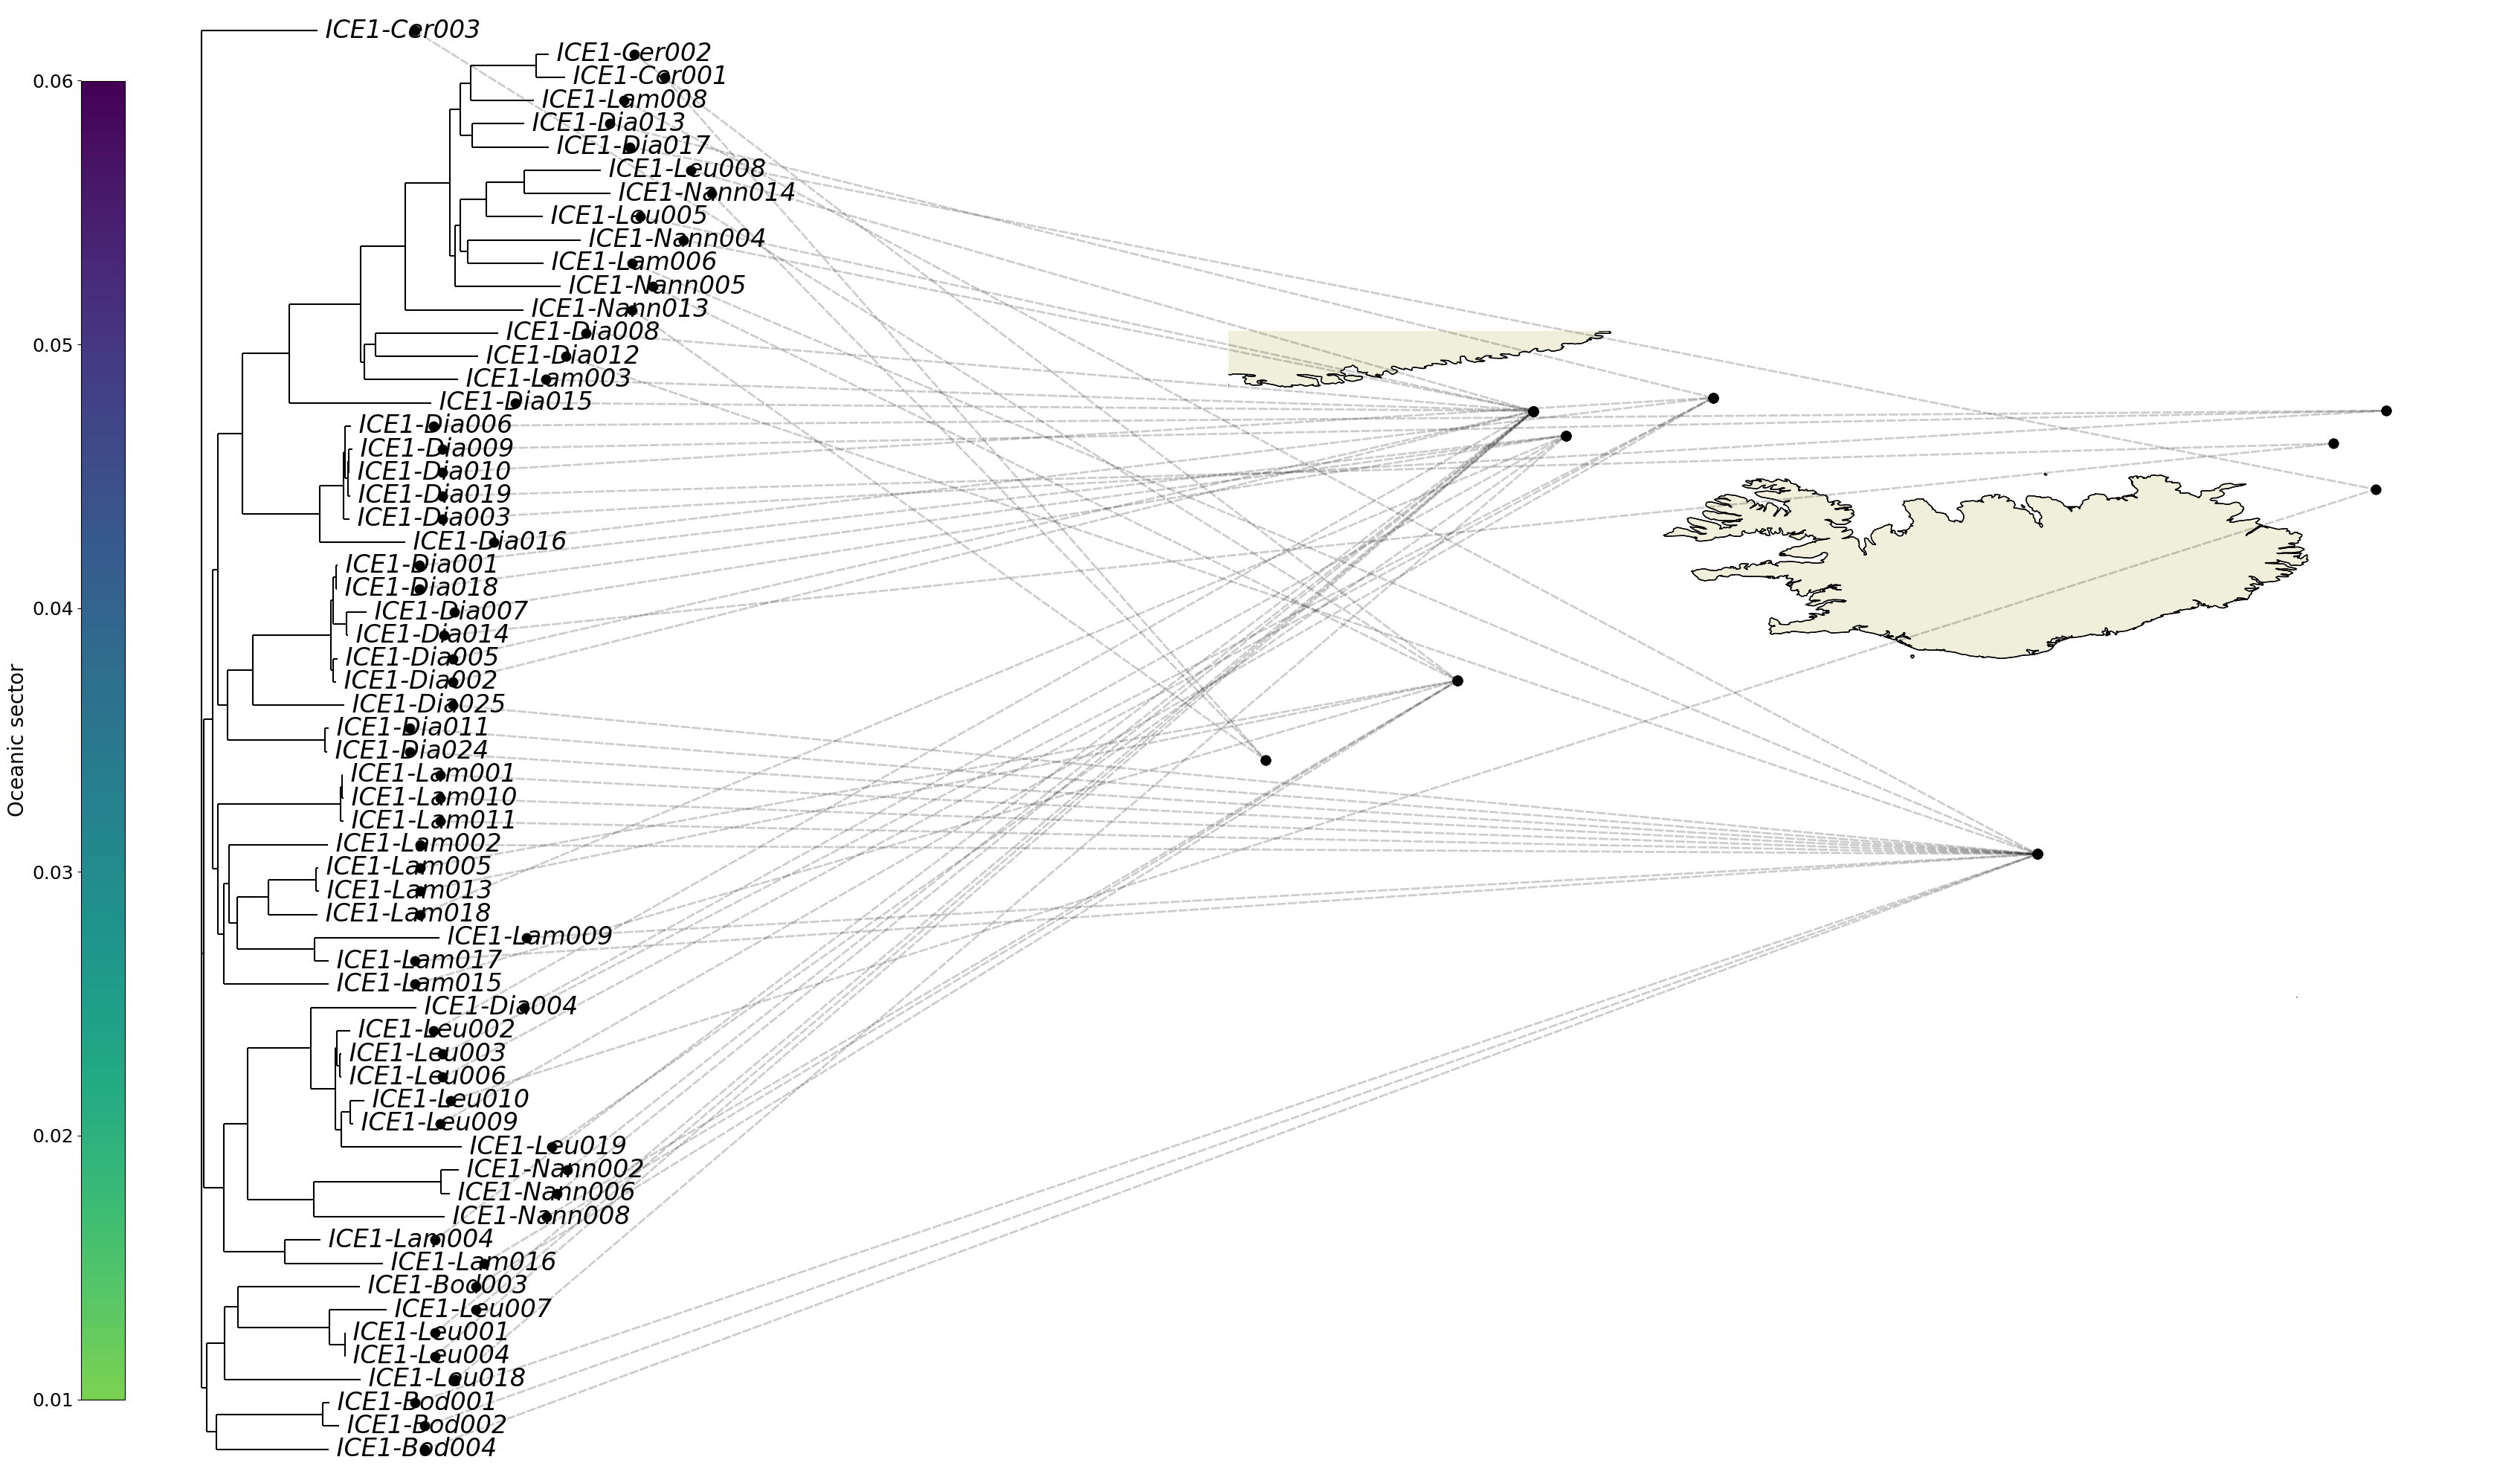

In [20]:
# Create the visualization
fig_map = plotter_map.plot(figsize=(35, 20))

# Display in notebook
plotter_map.show()

### Save the Output

In [16]:
# Save as SVG and PNG
svg_file, png_file = plotter_map.save(output_dir=str(output_dir), prefix='cumacea_north_atlantic')

print(f"\n✓ Files saved to {output_dir}")


✓ Saved SVG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\use_case_2\cumacea_north_atlantic_to_map_20260314_182501.svg
✓ Saved PNG: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\use_case_2\cumacea_north_atlantic_to_map_20260314_182501.png

✓ Files saved to c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\output\use_case_2


## Cleanup

Close all figures to free memory.

In [17]:
# Close all figures

plotter_map.close()




## Summary

You've learned how to:

✅ Import and initialize `PhyloCartoPlotter`
✅ Create visualizations with raster layers
✅ Create visualizations with geographic maps
✅ Customize contrast enhancement methods
✅ Try different raster bands and colormaps
✅ Save outputs as SVG and PNG
✅ Use transparency and other visual parameters

### Key Files

- **Main class**: `scripts/visualization/tree_to_map_raster.py`
- **Input data**: `input/` directory
- **Output files**: `output/` directory

### Next Steps

1. Explore different raster bands (1-9)
2. Try different contrast methods
3. Customize the map extent for your study region
4. Adjust trait value ranges (vmin, vmax) for your data
5. Use SVG output for publications (vector format)
6. Use PNG output for presentations (raster format)